<img src="images/Cat.jpg" alt="Cat" width="120" style="float: right; margin-left: 16px; border-radius: 6px;" />

<h1 style="margin: 0 0 6px 0; line-height: 1.1;">Audiological Analysis of Speech Understanding in Noise</h1>

This notebook analyzes data from the PAHRE clinical validation study.

Notebook coded by Oskar Gyllenör, an enthusiastic audiologist, tester, and software engineering student.<br>
(Picture is not a representation of the author.)

## Project Goal

The goal of this project is to investigate whether speech understanding in noise becomes worse with age and high-frequency hearing loss, and whether Lombard speech appears to improve listening performance.

## Dataset Context

The dataset comes from a clinical validation study of the PAHRE test, which stands for *Prueba Auditiva de Habla en Ruido en Espanol*. PAHRE is a Spanish speech-in-noise test designed to measure how well people understand speech when background babble noise is present. <br> For Swedish readers, imagine "Folk babblar"

The study also examines the Lombard effect. This is when a speaker naturally changes their voice in noisy environments, often by increasing vocal intensity and changing speech characteristics. Something we all do without thinking about. <br>In this dataset, some test conditions use standard speech and others use Lombard speech.

The dataset contains demographic variables such as age, sex, and education level, together with hearing-related variables and speech-in-noise performance scores.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_spss("data/test_data.sav")

df.head()

,SEX,AGE,AGEGROUP,STUDIES,DROP4kHz,SLOPECURVE,BLOCK,NLB12,NLB6,NLB3,...,NLA0,NLA3_A,NLA6_A,LA12,LA6,LA3,LA0,LA3_A,LA6_A,filter_$
0,hombre,18.0,18-49,bachillerato,NO,NORMAL,10.0,4.0,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
1,hombre,18.0,18-49,bachillerato,NO,NORMAL,6.0,5.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
2,hombre,19.0,18-49,bachillerato,NO,NORMAL,14.0,5.0,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
3,mujer,19.0,18-49,bachillerato,NO,NORMAL,15.0,5.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected
4,mujer,20.0,18-49,bachillerato,NO,NORMAL,12.0,5.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Selected


## First Inspection

Before analyzing the data, I inspect the shape, column names, data types, and missing values. This helps me understand what kind of cleaning is needed.

In [2]:
print(f"Rows and columns: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")

df.info()

Rows and columns: (144, 70)
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 70 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   SEX         144 non-null    category
 1   AGE         144 non-null    float64 
 2   AGEGROUP    144 non-null    category
 3   STUDIES     144 non-null    category
 4   DROP4kHz    144 non-null    category
 5   SLOPECURVE  144 non-null    category
 6   BLOCK       144 non-null    float64 
 7   NLB12       144 non-null    float64 
 8   NLB6        144 non-null    float64 
 9   NLB3        144 non-null    float64 
 10  NLB0        144 non-null    float64 
 11  NLB3_A      144 non-null    float64 
 12  NLB6_A      144 non-null    float64 
 13  PLUSNLBIN   144 non-null    float64 
 14  SRTNLBIN1   144 non-null    float64 
 15  SRTNLBIN2   144 non-null    float64 
 16  LB12        144 non-null    float64 
 17  LB6         144 non-null    float64 
 18  LB3         144

In [3]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

LOD0       144
LOD12      144
LOD3_A     144
SRTNLOD    144
PLUSLOD    144
NLOD6_A    144
NLA6_A     144
LA12       144
LA6        144
NLA12      144
NLA6       144
NLA3       144
LOD3       144
LOD6       144
NLOD6      144
NLOD3      144
NLOD0      144
NLOD3_A    144
NLOD12     144
SRTLOI     144
SUMALOI    144
LOI6_A     144
LOI3_A     144
LOI0       144
LOI3       144
LOI6       144
LOI12      144
SRTNLOI    144
PLUSLOI    144
NLOI6_A    144
NLOI3_A    144
NLOI0      144
NLOI3      144
NLOI6      144
NLOI12     144
SRTLOD     144
SUMALOD    144
LOD6_A     144
LA0        144
LA3_A      144
LA6_A      144
LA3        144
NLA0       144
NLA3_A     144
dtype: int64

In [4]:
df.describe()

,AGE,BLOCK,NLB12,NLB6,NLB3,NLB0,NLB3_A,NLB6_A,PLUSNLBIN,SRTNLBIN1,...,NLA3,NLA0,NLA3_A,NLA6_A,LA12,LA6,LA3,LA0,LA3_A,LA6_A
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,48.166667,7.500000,4.937500,4.618056,4.284722,3.159722,0.875000,0.020833,17.895833,2.762500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,14.700744,4.506406,0.294916,0.923633,1.168725,1.819334,1.294826,0.143325,3.348559,2.009136,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,18.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,-1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,4.000000,5.000000,5.000000,4.000000,2.000000,0.000000,0.000000,16.000000,1.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,46.000000,7.000000,5.000000,5.000000,5.000000,3.000000,0.000000,0.000000,18.000000,2.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,60.000000,11.000000,5.000000,5.000000,5.000000,5.000000,1.000000,0.000000,20.000000,3.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,85.000000,16.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,25.000000,10.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(144, 70)

In [6]:
df["SEX"].value_counts()

SEX
hombre    94
mujer     50
Name: count, dtype: int64

In [7]:
df.columns.tolist()

['SEX',
 'AGE',
 'AGEGROUP',
 'STUDIES',
 'DROP4kHz',
 'SLOPECURVE',
 'BLOCK',
 'NLB12',
 'NLB6',
 'NLB3',
 'NLB0',
 'NLB3_A',
 'NLB6_A',
 'PLUSNLBIN',
 'SRTNLBIN1',
 'SRTNLBIN2',
 'LB12',
 'LB6',
 'LB3',
 'LB0',
 'LB3_A',
 'LB6_A',
 'PLUSLCIN',
 'SRTLBIN1',
 'SRTLBIN2',
 'NLOD12',
 'NLOD6',
 'NLOD3',
 'NLOD0',
 'NLOD3_A',
 'NLOD6_A',
 'PLUSLOD',
 'SRTNLOD',
 'LOD12',
 'LOD6',
 'LOD3',
 'LOD0',
 'LOD3_A',
 'LOD6_A',
 'SUMALOD',
 'SRTLOD',
 'NLOI12',
 'NLOI6',
 'NLOI3',
 'NLOI0',
 'NLOI3_A',
 'NLOI6_A',
 'PLUSLOI',
 'SRTNLOI',
 'LOI12',
 'LOI6',
 'LOI3',
 'LOI0',
 'LOI3_A',
 'LOI6_A',
 'SUMALOI',
 'SRTLOI',
 'NLA12',
 'NLA6',
 'NLA3',
 'NLA0',
 'NLA3_A',
 'NLA6_A',
 'LA12',
 'LA6',
 'LA3',
 'LA0',
 'LA3_A',
 'LA6_A',
 'filter_$']

In [8]:
df["AGEGROUP"].value_counts()

AGEGROUP
18-49    86
50-59    21
60-69    21
70-79    15
>80       1
Name: count, dtype: int64

In [9]:
df["DROP4kHz"].value_counts()

DROP4kHz
NO    94
SI    50
Name: count, dtype: int64

Strangely, the file contains 144 rows and 70 columns. The article context (where I got the data from) mentions 104 participants, but this data file does not include a participant ID column. Because of this, I treat the rows as observations in this file rather than confirmed unique participants.

The row counts also add up to 144 when grouped by sex, age group, and high-frequency hearing loss status, which confirms that the notebook is reading the full file correctly.

## Data Cleaning

Many columns in the file are completely empty. As far as I know, this is common in clinical SPSS datasets, where files may include columns for alternative test conditions, repeated measurement templates, or even variables that were not used in the final analysis.

In this dataset, the empty columns do not contribute information to the current analysis, so I remove all columns where values are missing. This keeps the analysis focused on the demographic variables and the PAHRE speech-in-noise scores that are actually present in the file.

In [10]:
df_clean = df.dropna(axis=1, how="all").copy()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

df_clean.columns.tolist()

Original shape: (144, 70)
Cleaned shape: (144, 26)


['SEX',
 'AGE',
 'AGEGROUP',
 'STUDIES',
 'DROP4kHz',
 'SLOPECURVE',
 'BLOCK',
 'NLB12',
 'NLB6',
 'NLB3',
 'NLB0',
 'NLB3_A',
 'NLB6_A',
 'PLUSNLBIN',
 'SRTNLBIN1',
 'SRTNLBIN2',
 'LB12',
 'LB6',
 'LB3',
 'LB0',
 'LB3_A',
 'LB6_A',
 'PLUSLCIN',
 'SRTLBIN1',
 'SRTLBIN2',
 'filter_$']

## Variables Used in This Analysis

To keep the analysis focused, I chose to use a smaller set of variables connected to the project goal:

- `AGE`: participant age, duh
- `AGEGROUP`: age group, 18-49, 50-59, 60-69, 70-70, >80
- `SEX`: participant sex
- `STUDIES`: education level
- `DROP4kHz`: whether the participant has a high-frequency drop-off around 4000 Hz
- `SRTNLBIN1`: speech reception threshold in the non-Lombard condition. Lower values mean better speech understanding.
- `SRTLBIN1`: speech reception threshold in the Lombard condition. Lower values mean better speech understanding.
- `PLUSNLBIN`: total score in the non-Lombard condition. Higher values mean better performance.
- `PLUSLCIN`: total score in the Lombard condition. Higher values mean better performance.

For SRT variables, lower values represent better speech understanding in noise.

In [11]:
analysis_columns = [
    "AGE",
    "AGEGROUP",
    "SEX",
    "STUDIES",
    "DROP4kHz",
    "SRTNLBIN1",
    "SRTLBIN1",
    "PLUSNLBIN",
    "PLUSLCIN",
]

analysis_df = df_clean[analysis_columns].copy()

analysis_df.head()

,AGE,AGEGROUP,SEX,STUDIES,DROP4kHz,SRTNLBIN1,SRTLBIN1,PLUSNLBIN,PLUSLCIN
0,18.0,18-49,hombre,bachillerato,NO,2.7,0.3,18.0,22.0
1,18.0,18-49,hombre,bachillerato,NO,3.9,-3.9,16.0,29.0
2,19.0,18-49,hombre,bachillerato,NO,4.5,-0.9,15.0,24.0
3,19.0,18-49,mujer,bachillerato,NO,3.9,-1.5,16.0,25.0
4,20.0,18-49,mujer,bachillerato,NO,0.9,-2.7,21.0,27.0


## Pandas Grouping and Filtering

Before visualizing the data, I use pandas to compare groups that are relevant to the project goal. I look at age groups and high-frequency hearing loss because both are expected to relate to speech understanding in noise.

In [12]:
agegroup_summary = (
    analysis_df
    .groupby("AGEGROUP", observed=True)
    .agg(
        observations=("AGE", "count"),
        mean_age=("AGE", "mean"),
        mean_srt_non_lombard=("SRTNLBIN1", "mean"),
        mean_srt_lombard=("SRTLBIN1", "mean"),
        mean_score_non_lombard=("PLUSNLBIN", "mean"),
        mean_score_lombard=("PLUSLCIN", "mean"),
    )
)

agegroup_summary

,observations,mean_age,mean_srt_non_lombard,mean_srt_lombard,mean_score_non_lombard,mean_score_lombard
AGEGROUP,,,,,,
18-49,86,38.406977,2.106977,-2.965116,18.988372,27.441860
50-59,21,52.952381,2.785714,-2.471429,17.857143,26.619048
60-69,21,63.761905,3.928571,-2.271429,15.952381,26.285714
70-79,15,73.133333,4.460000,-0.780000,15.066667,23.800000
>80,1,85.000000,8.700000,-0.300000,8.000000,23.000000


In [13]:
drop4khz_yes = analysis_df[analysis_df["DROP4kHz"] == "SI"]
drop4khz_no = analysis_df[analysis_df["DROP4kHz"] == "NO"]

print(f"Rows with high-frequency drop-off: {len(drop4khz_yes)}")
print(f"Rows without high-frequency drop-off: {len(drop4khz_no)}")

Rows with high-frequency drop-off: 50
Rows without high-frequency drop-off: 94


In [14]:
drop4khz_summary = (
    analysis_df
    .groupby("DROP4kHz", observed=True)
    .agg(
        observations=("AGE", "count"),
        mean_age=("AGE", "mean"),
        mean_srt_non_lombard=("SRTNLBIN1", "mean"),
        mean_srt_lombard=("SRTLBIN1", "mean"),
    )
)

drop4khz_summary

,observations,mean_age,mean_srt_non_lombard,mean_srt_lombard
DROP4kHz,,,,
NO,94,42.670213,2.368085,-2.917021
SI,50,58.500000,3.504000,-1.848000


## Translated Terms

Some category labels in the dataset are written in Spanish. I keep the original values in the dataframe, but translate the most important terms here so the analysis is easier to follow.

| Original term  | English meaning |
|----------------|---|
| hombre         | man |
| mujer          | woman |
| PRIMARIA       | primary school |
| ESO            | compulsory secondary education |
| Bachillerato   | upper secondary / high school track |
| FP MEDIO       | intermediate vocational training |
| FP SUPERIOR    | higher vocational training |
| UNIVERSITARIOS | university studies |
| MASTER         | master's degree |
| DOCTORADO      | doctorate / PhD |
| SI             | yes |
| NO             | no |

I do not replace the original values in the dataframe because keeping the source labels makes it easier to trace the analysis back to the original dataset.

## Visualization 1: Age Distribution

Question: What does the age distribution of the observations look like?

This matters because age is one of the main factors being investigated in relation to speech understanding in noise. <br>
Mostly due to the presence of Presbyacusis

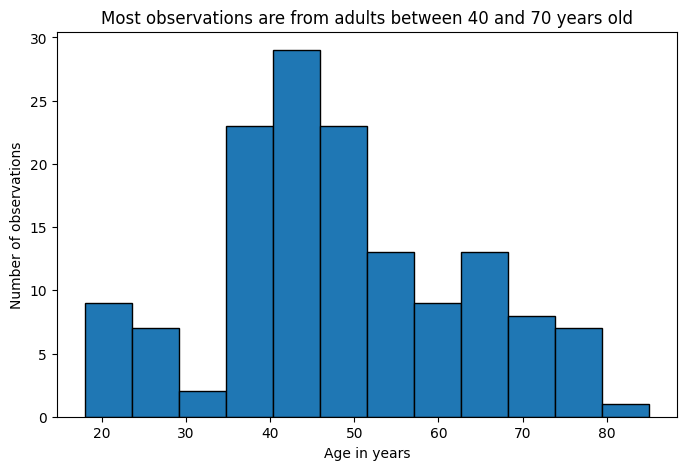

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(analysis_df["AGE"], bins=12, edgecolor="black")

ax.set_title("Most observations are from adults between 40 and 70 years old")
ax.set_xlabel("Age in years")
ax.set_ylabel("Number of observations")

plt.show()